In [ ]:
!pip install faker

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from faker import Faker

Install & Import

In [ ]:
fake = Faker()
np.random.seed(42)

Initialize Faker

In [ ]:
num_students = 250

data = []

for i in range(1, num_students + 1):
    student = {
        "Student_ID": f"S{i:03}",
        "Name": fake.name(),
        "Gender": np.random.choice(['Male', 'Female']),
        "Department": np.random.choice(['CSE', 'IT', 'ECE']),
        "Year": np.random.choice(['1st', '2nd', '3rd']),
        "Maths": np.random.randint(40, 100),
        "Science": np.random.randint(40, 100),
        "English": np.random.randint(40, 100),
        "Attendance": np.random.randint(50, 101),
        "Internal Marks": np.random.randint(0, 26)
    }
    data.append(student)

df = pd.DataFrame(data)

df.head()

,Student_ID,Name,Gender,Department,Year,Maths,Science,English,Attendance,Internal Marks
0,S001,Rose Acosta,Male,CSE,3rd,82,47,60,88,25
1,S002,Jeremiah Thomas,Male,ECE,3rd,50,63,92,85,7
2,S003,Danielle Lewis,Female,ECE,2nd,92,41,63,93,5
3,S004,Jacob Weaver,Female,CSE,1st,51,97,61,93,24
4,S005,Jason Black,Male,ECE,3rd,81,67,99,65,14


Generate Synthetic Data with Faker

In [ ]:
df['Total'] = df[['Maths', 'Science', 'English']].sum(axis=1)
df['Average'] = df['Total'] / 3

def assign_grade(avg):
    if avg >= 85:
        return 'A'
    elif avg >= 70:
        return 'B'
    elif avg >= 50:
        return 'C'
    else:
        return 'Fail'

df['Grade'] = df['Average'].apply(assign_grade)

df.head()

,Student_ID,Name,Gender,Department,Year,Maths,Science,English,Attendance,Internal Marks,Total,Average,Grade
0,S001,Rose Acosta,Male,CSE,3rd,82,47,60,88,25,189,63.000000,C
1,S002,Jeremiah Thomas,Male,ECE,3rd,50,63,92,85,7,205,68.333333,C
2,S003,Danielle Lewis,Female,ECE,2nd,92,41,63,93,5,196,65.333333,C
3,S004,Jacob Weaver,Female,CSE,1st,51,97,61,93,24,209,69.666667,C
4,S005,Jason Black,Male,ECE,3rd,81,67,99,65,14,247,82.333333,B


Data Processing

In [ ]:
df.describe()

,Maths,Science,English,Attendance,Internal Marks,Total,Average
count,250.00000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,69.41600,72.284000,69.440000,76.832000,13.296000,211.140000,70.380000
std,17.15354,17.219448,17.484772,14.769031,7.597319,30.221412,10.073804
min,40.00000,40.000000,40.000000,50.000000,0.000000,129.000000,43.000000
25%,53.00000,58.250000,54.000000,65.000000,7.000000,191.250000,63.750000
50%,71.00000,74.500000,69.000000,78.000000,13.000000,212.000000,70.666667
75%,83.75000,87.000000,84.750000,89.000000,20.750000,231.750000,77.250000
max,99.00000,99.000000,99.000000,100.000000,25.000000,283.000000,94.333333


Basic Statistics

In [ ]:
df.sort_values(by='Total', ascending=False).head(10)[['Name', 'Total']]

,Name,Total
247,Robert Flores,283
211,Shannon Wood,279
28,Briana Thomas,276
232,Kathryn Oconnor,275
38,Jason Faulkner,274
23,Keith Kelley,272
176,Ricky Gibson,271
106,Christopher Shah,271
87,Shawn Hall,270
62,Natalie Hamilton,269


Top Performers

In [ ]:
df[df['Grade'] == 'Fail'][['Name', 'Average']]

,Name,Average
16,Laura Byrd,48.666667
126,Carolyn Atkins,43.000000


Failed Students

In [ ]:
df.groupby('Department')['Average'].mean()
df.groupby('Gender')['Average'].mean()
df.groupby('Year')['Average'].mean()

,Average
Year,
1st,70.626506
2nd,69.747475
3rd,71.000000


Group Analysis

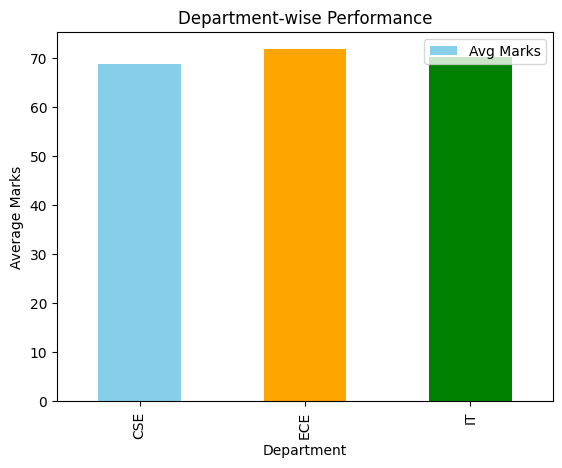

In [ ]:
dept_avg = df.groupby('Department')['Average'].mean()

dept_avg.plot(kind='bar', color=['skyblue', 'orange', 'green'], label='Avg Marks')

plt.title('Department-wise Performance')
plt.xlabel('Department')
plt.ylabel('Average Marks')
plt.legend()
plt.show()

Bar Chart

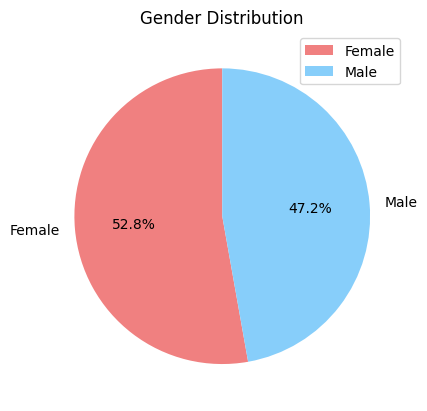

In [ ]:
gender_counts = df['Gender'].value_counts()

colors = ['lightcoral', 'lightskyblue']

gender_counts.plot(kind='pie', autopct='%1.1f%%', colors=colors, startangle=90)

plt.title('Gender Distribution')
plt.legend(gender_counts.index, loc='upper right')
plt.ylabel('')
plt.show()

Pie Chart

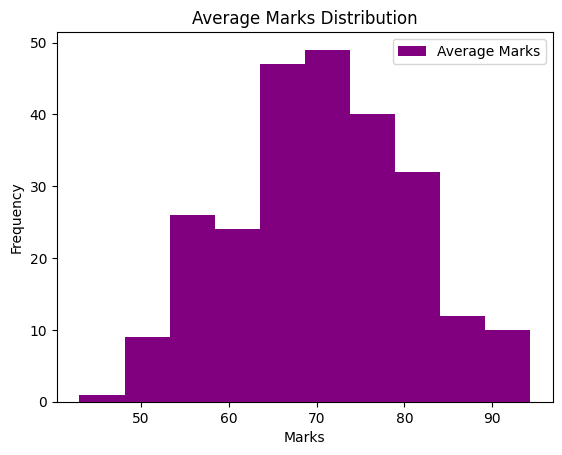

In [ ]:
plt.hist(df['Average'], bins=10, color='purple', label='Average Marks')

plt.title('Average Marks Distribution')
plt.xlabel('Marks')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Histogram

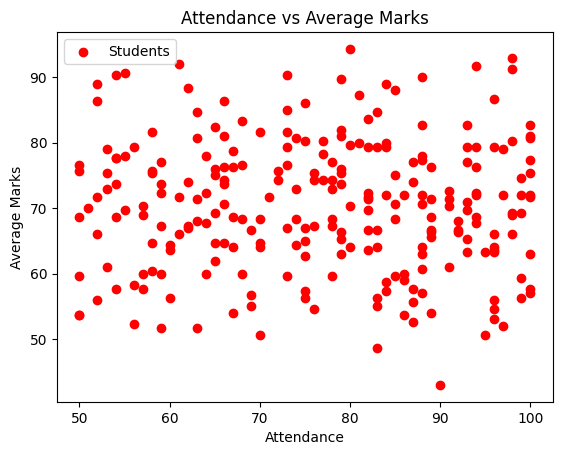

In [ ]:
plt.scatter(df['Attendance'], df['Average'], color='red', label='Students')

plt.title('Attendance vs Average Marks')
plt.xlabel('Attendance')
plt.ylabel('Average Marks')
plt.legend()
plt.show()

Scatter Plot

In [ ]:
df.to_csv('student_performance_faker.csv', index=False)

In [ ]:
plt.style.use('ggplot')